### This code is a copy of the Deblur Analysis from the coco dataset

In [1]:
# Code block generated with Gemini; prompt "All seeds needed for reproducibility in pytorch based DL project"

import os
import random
import numpy as np
import torch

def set_all_seeds(seed_value=42):
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_all_seeds(42)

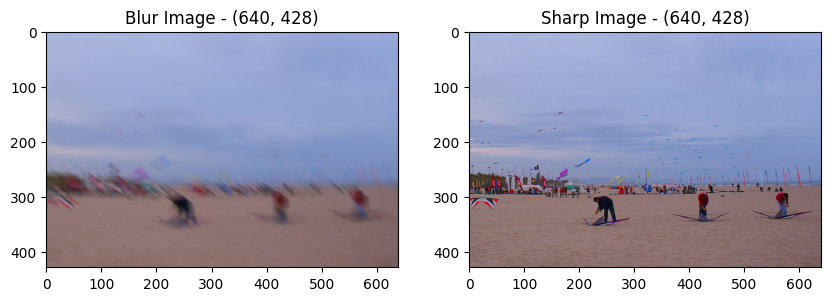

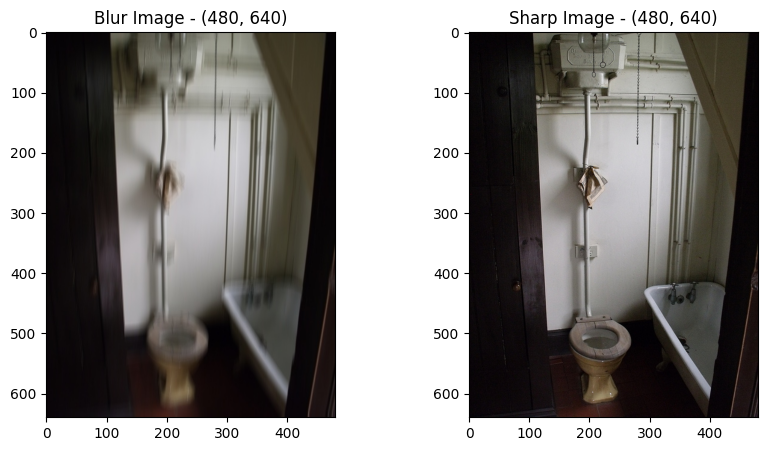

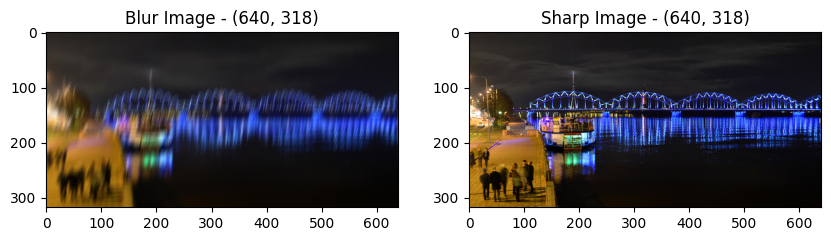

Total blur images: 5000
Total sharp images: 5000


In [2]:
from PIL import Image
import random, os
import matplotlib.pyplot as plt

root_dir = "coco_val_data_and_annots"

def choose_and_plot_random_blur_and_unblur(root_dir):
    selected_blur_file = random.choice(os.listdir(os.path.join(root_dir, "blurred_images_coco")))
    blur_image_filename = os.path.join(root_dir, "blurred_images_coco", selected_blur_file)
    sharp_image_filename = os.path.join(root_dir, "sharp_images_coco", selected_blur_file)
    # print(blur_image_filename, sharp_image_filename)
    blur_image = Image.open(blur_image_filename)
    sharp_image = Image.open(sharp_image_filename)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(blur_image)
    axs[1].imshow(sharp_image)

    axs[0].set_title(f'Blur Image - {blur_image.size}')
    axs[1].set_title(f'Sharp Image - {sharp_image.size}')
    plt.show()



choose_and_plot_random_blur_and_unblur(root_dir)
choose_and_plot_random_blur_and_unblur(root_dir)
choose_and_plot_random_blur_and_unblur(root_dir)

print(f"Total blur images: {len(os.listdir(os.path.join(root_dir, 'blurred_images_coco')))}")
print(f"Total sharp images: {len(os.listdir(os.path.join(root_dir, 'sharp_images_coco')))}")

In [3]:
import cv2
from tqdm import tqdm
import numpy as np

def calculate_blur_score_fft(input_data, radius=30):
    if isinstance(input_data, str):
        img = cv2.imread(input_data, 0)
    else:
        if len(input_data.shape) == 3:
                # Handle float (0-1) vs uint8 (0-255)
                if input_data.dtype != np.uint8:
                    input_data = (input_data * 255).astype(np.uint8)
                img = cv2.cvtColor(input_data, cv2.COLOR_RGB2GRAY)
        else:
            img = input_data
    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft) # this function helps shift all the zero freq points to centre
    magnitude_spectrum = np.abs(dft_shift)
    mask = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), radius, 1, -1)
    low_freq_area = magnitude_spectrum * mask
    high_freq_area = magnitude_spectrum * (1 - mask)
    low_energy = np.sum(low_freq_area)
    high_energy = np.sum(high_freq_area)
    ratio = high_energy / low_energy
    return ratio

root_dir = "/home/nam/projects/sid/Motion-Deblurring/coco_val_data_and_annots/blurred_images_coco"
image_and_blur_score = []

for file in tqdm(os.listdir(root_dir)):
    full_path = os.path.join(root_dir, file)
    blur_score = calculate_blur_score_fft(full_path).item()
    image_and_blur_score.append([full_path, round(blur_score, 3)])

# Sorting in descending order according to blur_score, so that we can then split this into buckets of low, medium and high
# A high ratio means the image is sharp
sorted_blur_scores = sorted(image_and_blur_score, key=lambda x: x[1], reverse=True)

 19%|█▊        | 936/5000 [00:14<01:05, 62.15it/s]

100%|██████████| 5000/5000 [01:15<00:00, 66.15it/s]


1666 1667 1667


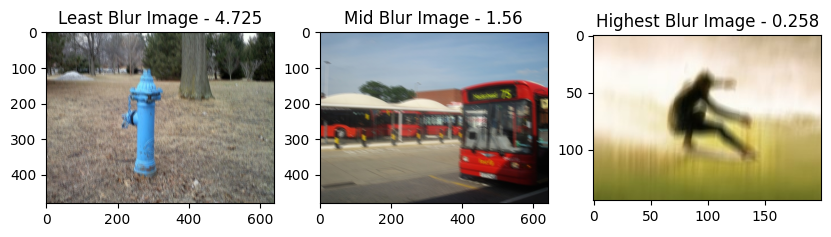

In [4]:
low_idx = len(sorted_blur_scores)//3
mid_idx = (len(sorted_blur_scores)*2)//3
high_idx = len(sorted_blur_scores)

low_blur_bucket, mid_blur_bucket, high_blur_bucket = sorted_blur_scores[:low_idx], sorted_blur_scores[low_idx:mid_idx], sorted_blur_scores[mid_idx:high_idx]
print(len(low_blur_bucket), len(mid_blur_bucket), len(high_blur_bucket))

low_blur_sample = low_blur_bucket[0]
mid_blur_sample = mid_blur_bucket[110]
high_blur_sample = high_blur_bucket[-1]

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(Image.open(low_blur_sample[0]))
axs[1].imshow(Image.open(mid_blur_sample[0]))
axs[2].imshow(Image.open(high_blur_sample[0]))

axs[0].set_title(f'Least Blur Image - {low_blur_sample[1]}')
axs[1].set_title(f'Mid Blur Image - {mid_blur_sample[1]}')
axs[2].set_title(f'Highest Blur Image - {high_blur_sample[1]}')
plt.show()

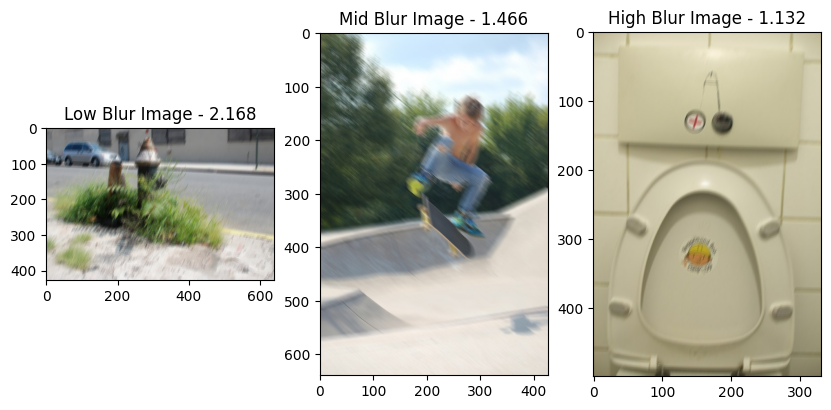

In [ ]:
low_blur_sample = random.choice(low_blur_bucket)
mid_blur_sample = random.choice(mid_blur_bucket)
high_blur_sample = random.choice(high_blur_bucket)

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(Image.open(low_blur_sample[0]))
axs[1].imshow(Image.open(mid_blur_sample[0]))
axs[2].imshow(Image.open(high_blur_sample[0]))

axs[0].set_title(f'Low Blur Image - {low_blur_sample[1]}')
axs[1].set_title(f'Mid Blur Image - {mid_blur_sample[1]}')
axs[2].set_title(f'High Blur Image - {high_blur_sample[1]}')
plt.show()

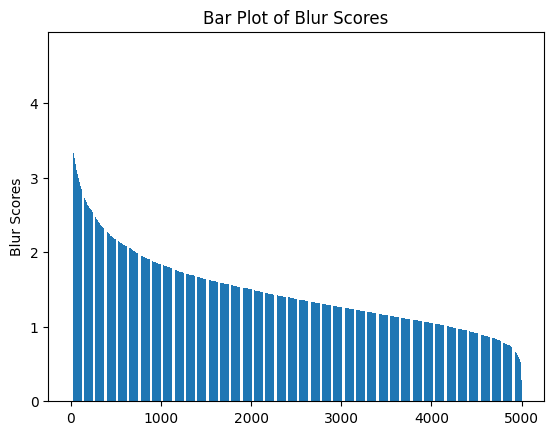

In [6]:
import matplotlib.pyplot as plt
import numpy as np

blur_scores_for_plot = [score[1] for score in sorted_blur_scores]
y_pos = np.arange(len(blur_scores_for_plot))
plt.bar(y_pos, blur_scores_for_plot)
plt.ylabel("Blur Scores")
plt.title("Bar Plot of Blur Scores")
plt.show()

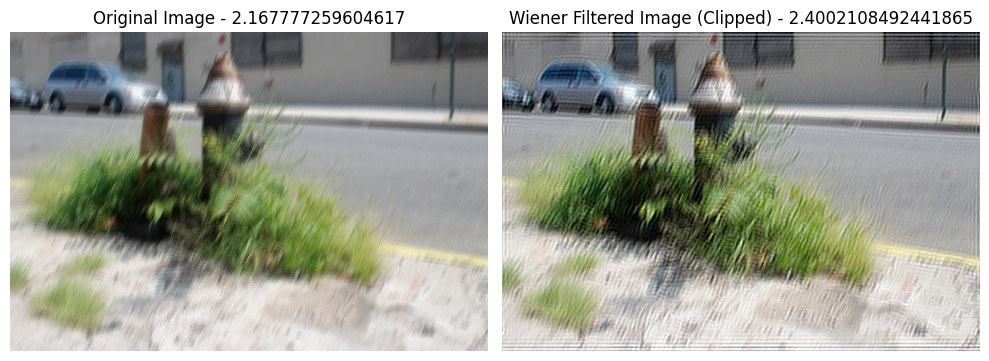

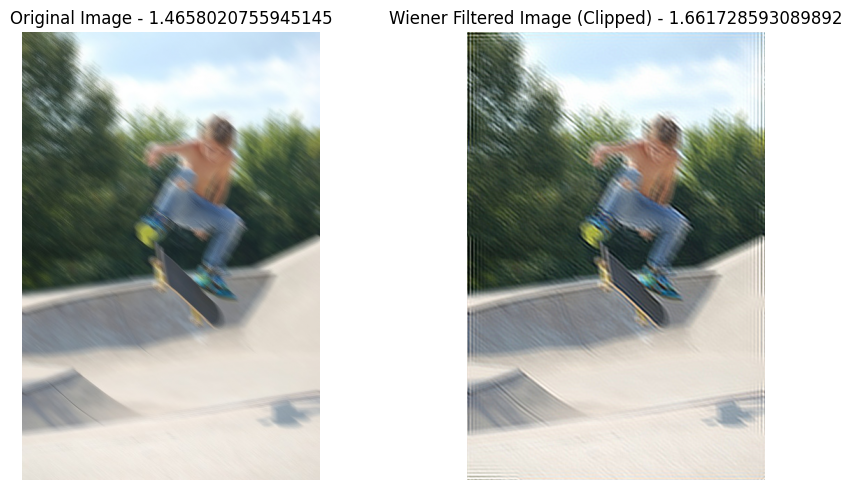

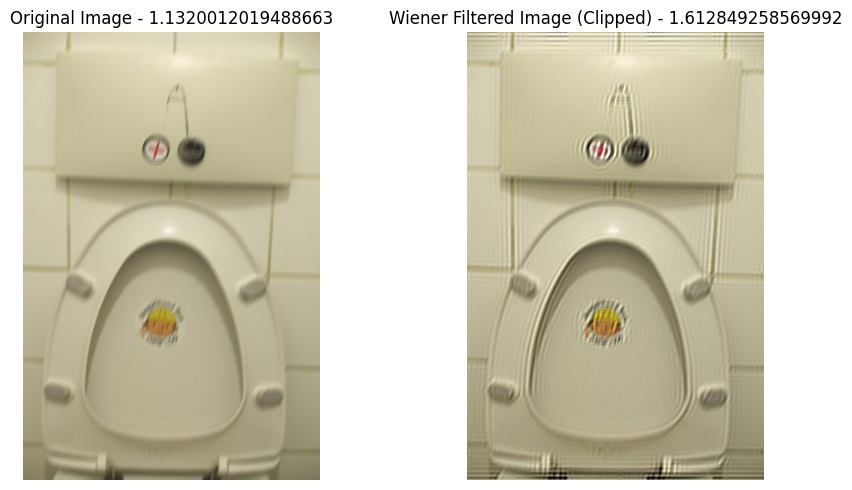

100%|██████████| 100/100 [00:14<00:00,  7.13it/s]


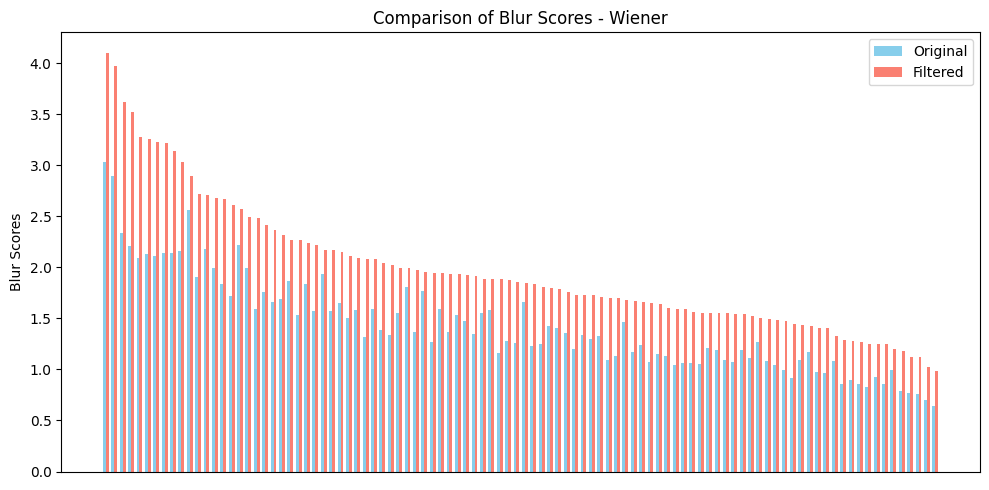

--- Blur Score Statistics ---
Average Original Score:  1.43
Average Filtered Score:  1.97
Average Absolute Increase: 0.54
Average Percentage Increase: 37.56%
Average PSNR score: 21.111179999999994
Average SSIM score: 0.5136299999999999
Highest single image improvement: 1.31


In [7]:
import numpy as np
from skimage import restoration
import io
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


def wiener_filtering_each_channel(blur_image_path, plot=False):
    original_blur_score = calculate_blur_score_fft(blur_image_path)
    blur_image = Image.open(blur_image_path)
    blur_image = np.array(blur_image) / 255.0
    psf = np.ones((5, 5)) / 25
    deconvolved_img = np.zeros_like(blur_image)
    
    for i in range(3):
        deconvolved_img[:, :, i] = restoration.wiener(blur_image[:, :, i], psf, balance=0.01)

    deconvolved_img = np.clip(deconvolved_img, 0, 1)
    filtered_blur_score = calculate_blur_score_fft(deconvolved_img)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        ax = axes.ravel()

        ax[0].imshow(blur_image)
        ax[0].set_title(f"Original Image - {original_blur_score}")
        ax[0].axis('off')

        ax[1].imshow(deconvolved_img)
        ax[1].set_title(f"Wiener Filtered Image (Clipped) - {filtered_blur_score}")
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()
    return deconvolved_img, original_blur_score, filtered_blur_score

wiener_filtering_each_channel(low_blur_sample[0], plot=True)
wiener_filtering_each_channel(mid_blur_sample[0], plot=True)
wiener_filtering_each_channel(high_blur_sample[0], plot=True)

image_and_blur_score = []
list_of_files = os.listdir("/home/nam/projects/sid/Motion-Deblurring/coco_val_data_and_annots/blurred_images_coco")
random.shuffle(list_of_files)
for image_file in tqdm(list_of_files[:100]):
    full_path = os.path.join("/home/nam/projects/sid/Motion-Deblurring/coco_val_data_and_annots/blurred_images_coco", image_file)
    full_path_sharp = os.path.join("/home/nam/projects/sid/Motion-Deblurring/coco_val_data_and_annots/sharp_images_coco", image_file)
    sharp_image = Image.open(full_path_sharp)
    sharp_image = np.array(sharp_image) / 255.0
    deblurred_img, original_score, filtered_blur_score = wiener_filtering_each_channel(full_path)
    psnr_score = round(psnr(sharp_image, deblurred_img, data_range=1.0), 3)
    ssim_score = round(ssim(sharp_image, deblurred_img, data_range=1.0, channel_axis=-1), 3)
    image_and_blur_score.append([full_path, original_score, filtered_blur_score, psnr_score, ssim_score])
    sorted_blur_scores = sorted(image_and_blur_score, key=lambda x: x[2], reverse=True)

original_blur_scores_for_plot = [score[1] for score in sorted_blur_scores]
blur_scores_for_plot = [score[2] for score in sorted_blur_scores]
psnr_score_for_plot = [score[3] for score in sorted_blur_scores]
ssim_score_for_plot = [score[4] for score in sorted_blur_scores]

x = np.arange(len(original_blur_scores_for_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, original_blur_scores_for_plot, width, label='Original', color='skyblue')
rects2 = ax.bar(x + width/2, blur_scores_for_plot, width, label='Filtered', color='salmon')

ax.set_ylabel("Blur Scores")
ax.set_title("Comparison of Blur Scores - Wiener")
ax.legend()
ax.set_xticks([])

plt.tight_layout()
plt.show()

differences = np.array(blur_scores_for_plot) - np.array(original_blur_scores_for_plot)
avg_increase = np.mean(differences)

avg_original = np.mean(np.array(original_blur_scores_for_plot))
percent_increase = (avg_increase / avg_original) * 100

print(f"--- Blur Score Statistics ---")
print(f"Average Original Score:  {avg_original:.2f}")
print(f"Average Filtered Score:  {np.mean(blur_scores_for_plot):.2f}")
print(f"Average Absolute Increase: {avg_increase:.2f}")
print(f"Average Percentage Increase: {percent_increase:.2f}%")
print(f"Average PSNR score: {np.mean(psnr_score_for_plot)}")
print(f"Average SSIM score: {np.mean(ssim_score_for_plot)}")

best_improvement = np.max(differences)
print(f"Highest single image improvement: {best_improvement:.2f}")

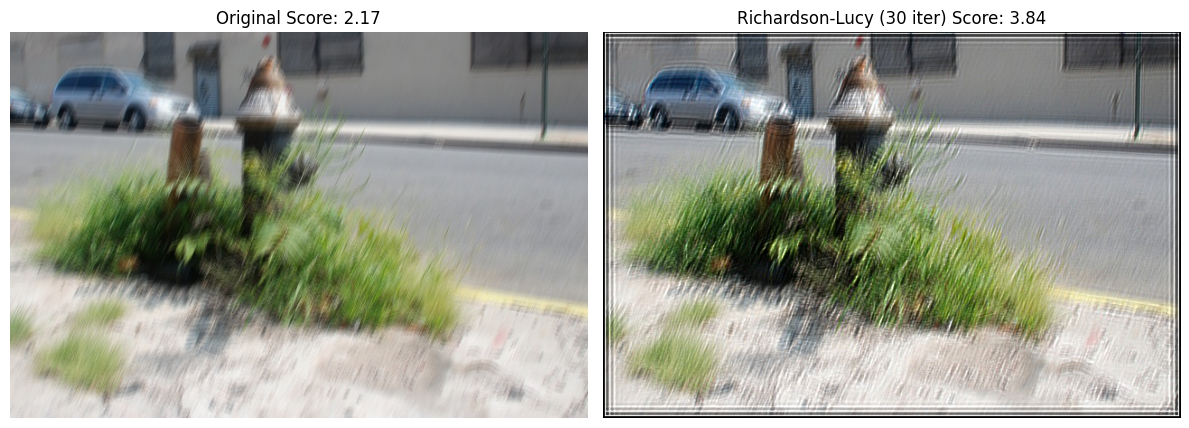

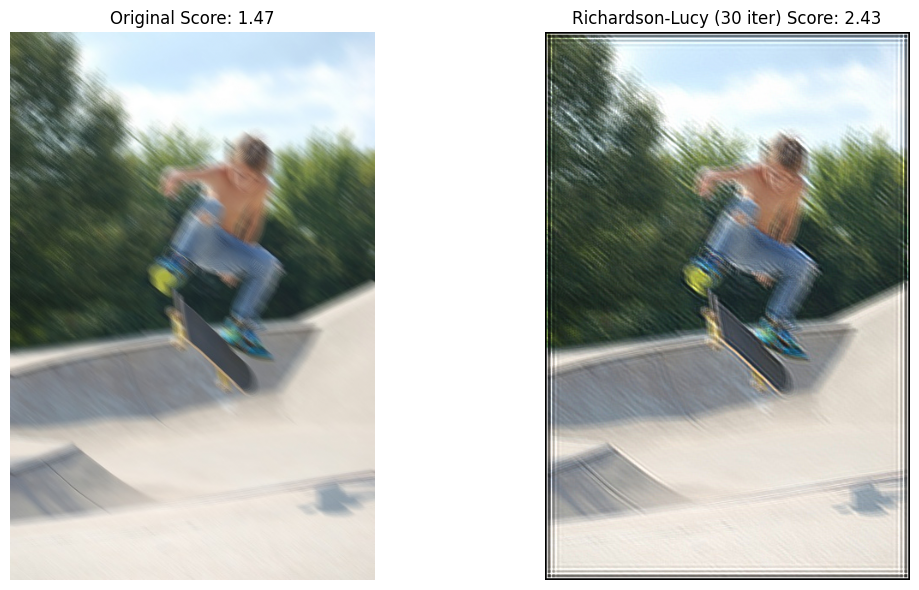

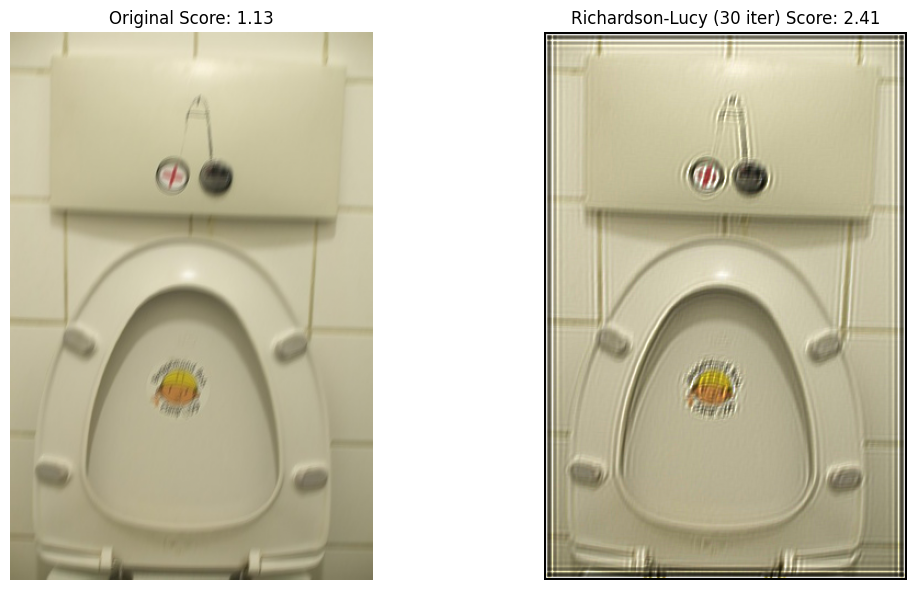

  2%|▏         | 2/100 [00:02<02:17,  1.40s/it]

100%|██████████| 100/100 [02:14<00:00,  1.34s/it]


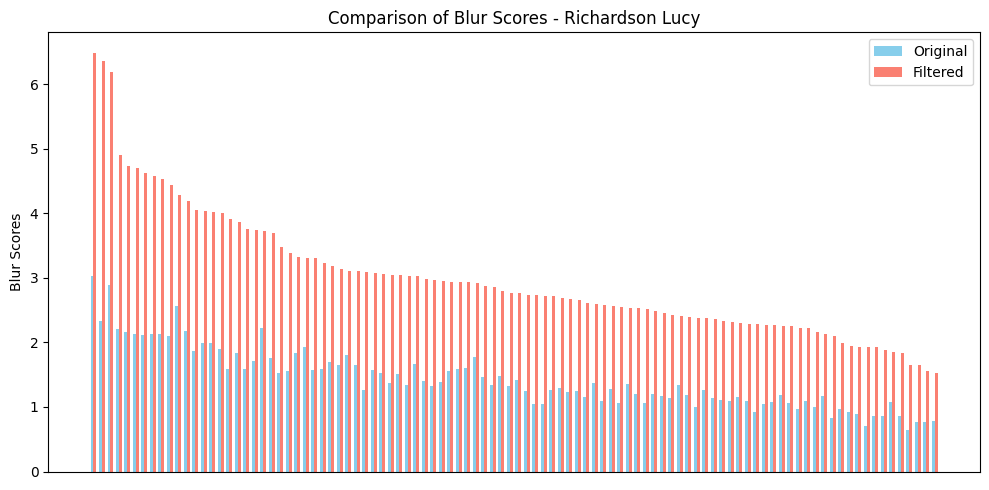

--- Blur Score Statistics ---
Average Original Score:  1.43
Average Filtered Score:  2.99
Average Absolute Increase: 1.56
Average Percentage Increase: 108.66%
Average PSNR score: 17.86433
Average SSIM score: 0.48239999999999994
Highest single image improvement: 4.02


In [8]:
import numpy as np
from skimage import restoration
from PIL import Image
import matplotlib.pyplot as plt

def richardson_lucy_filtering_each_channel(blur_image_path, iterations=30, plot=False):
    original_blur_score = calculate_blur_score_fft(blur_image_path)
    blur_image = Image.open(blur_image_path).convert("RGB")
    blur_image = np.array(blur_image) / 255.0
    psf = np.ones((5, 5)) / 25
    
    deconvolved_img = np.zeros_like(blur_image)
    
    for i in range(3):
        # Richardson-Lucy deconvolution
        deconvolved_img[:, :, i] = restoration.richardson_lucy(
            blur_image[:, :, i], 
            psf, 
            num_iter=iterations
        )
    deconvolved_img = np.clip(deconvolved_img, 0, 1)
    filtered_blur_score = calculate_blur_score_fft(deconvolved_img)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        ax = axes.ravel()

        ax[0].imshow(blur_image)
        ax[0].set_title(f"Original Score: {original_blur_score:.2f}")
        ax[0].axis('off')

        ax[1].imshow(deconvolved_img)
        ax[1].set_title(f"Richardson-Lucy ({iterations} iter) Score: {filtered_blur_score:.2f}")
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()

    return deconvolved_img, original_blur_score, filtered_blur_score


richardson_lucy_filtering_each_channel(low_blur_sample[0], plot=True)
richardson_lucy_filtering_each_channel(mid_blur_sample[0], plot=True)
richardson_lucy_filtering_each_channel(high_blur_sample[0], plot=True)

image_and_blur_score = []
for image_file in tqdm(list_of_files[:100]):
    full_path = os.path.join("/home/nam/projects/sid/Motion-Deblurring/coco_val_data_and_annots/blurred_images_coco", image_file)
    full_path_sharp = os.path.join("/home/nam/projects/sid/Motion-Deblurring/coco_val_data_and_annots/sharp_images_coco", image_file)
    sharp_image = Image.open(full_path_sharp)
    sharp_image = np.array(sharp_image) / 255.0
    deblurred_img, original_score, filtered_blur_score = richardson_lucy_filtering_each_channel(full_path)
    deblurred_img_uint8 = (deblurred_img * 255).astype(np.uint8)
    deblurred_img_pil = Image.fromarray(deblurred_img_uint8)
    deblurred_img_pil.save(f"coco_val_data_and_annots/richarlson_lucy_deblur_coco_2017/{image_file}")
    psnr_score = round(psnr(sharp_image, deblurred_img, data_range=1.0), 3)
    ssim_score = round(ssim(sharp_image, deblurred_img, data_range=1.0, channel_axis=-1), 3)
    image_and_blur_score.append([full_path, original_score, filtered_blur_score, psnr_score, ssim_score])
    sorted_blur_scores = sorted(image_and_blur_score, key=lambda x: x[2], reverse=True)

original_blur_scores_for_plot = [score[1] for score in sorted_blur_scores]
blur_scores_for_plot = [score[2] for score in sorted_blur_scores]
psnr_score_for_plot = [score[3] for score in sorted_blur_scores]
ssim_score_for_plot = [score[4] for score in sorted_blur_scores]

x = np.arange(len(original_blur_scores_for_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, original_blur_scores_for_plot, width, label='Original', color='skyblue')
rects2 = ax.bar(x + width/2, blur_scores_for_plot, width, label='Filtered', color='salmon')
ax.set_ylabel("Blur Scores")
ax.set_title("Comparison of Blur Scores - Richardson Lucy")
ax.legend()
ax.set_xticks([])

plt.tight_layout()
plt.show()

differences = np.array(blur_scores_for_plot) - np.array(original_blur_scores_for_plot)
avg_increase = np.mean(differences)

avg_original = np.mean(np.array(original_blur_scores_for_plot))
percent_increase = (avg_increase / avg_original) * 100

print(f"--- Blur Score Statistics ---")
print(f"Average Original Score:  {avg_original:.2f}")
print(f"Average Filtered Score:  {np.mean(blur_scores_for_plot):.2f}")
print(f"Average Absolute Increase: {avg_increase:.2f}")
print(f"Average Percentage Increase: {percent_increase:.2f}%")
print(f"Average PSNR score: {np.mean(psnr_score_for_plot)}")
print(f"Average SSIM score: {np.mean(ssim_score_for_plot)}")

best_improvement = np.max(differences)
print(f"Highest single image improvement: {best_improvement:.2f}")

### Comparing the 3 models used
> ***Blur Score Statistics for Wiener Filtering***
>
> Average Original Score:  1.43
>
> Average Filtered Score:  1.97
>
> Average Absolute Increase: 0.54
>
> Average Percentage Increase: 37.56%
>
> Average PSNR score: 21.111179999999994
>
> Average SSIM score: 0.51363
>
> Highest single image improvement: 1.31
------
> ***Blur Score Statistics for Richardson Lucy Filtering***
> 
> Average Original Score:  1.43
>
> Average Filtered Score:  2.99
>
> Average Absolute Increase: 1.56
>
> Average Percentage Increase: 108.66%
>
> Average PSNR score: 17.86433
>
> Average SSIM score: 0.4824
>
> Highest single image improvement: 4.02
-------

### I have chosen Wiener filtering from my experiments. It performs really good deblurring(on the coco dataset) while we dont need to resize it like the Deep Learning based methods.

- The following cell, we deblur the entire dataset and save it locally so that we load it so that we can load it onto disk easily.
- This way we can also see the effect on the full dataset. Above we had analysed only 100 samples from the dataset.
- The code for the same can be found in `wiener_filter_deblur_full_dataset.py`